In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import statsmodels
import yfinance as yf

print("Setup works!")

Setup works!


In [25]:
tickers = ["SPY", "AAPL"]
start_date = "2022-01-01"
end_date = "2025-12-31"

In [26]:
import yfinance as yf

spy = yf.download(
    "SPY",
    start="2022-01-01",
    end="2026-01-01",
    auto_adjust=False
)

aapl = yf.download(
    "AAPL",
    start="2022-01-01",
    end="2026-01-01",
    auto_adjust=False
)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [27]:
spy.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2022-01-03,449.486450,477.709991,477.850006,473.850006,476.299988,72668200
2022-01-04,449.335907,477.549988,479.980011,475.579987,479.220001,71178700
2022-01-05,440.707672,468.380005,477.980011,468.279999,477.160004,104538900
2022-01-06,440.293671,467.940002,470.820007,465.429993,467.890015,86858900
2022-01-07,438.553040,466.089996,469.200012,464.649994,467.950012,85111600


In [28]:
aapl.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2022-01-03,177.786377,182.009995,182.880005,177.710007,177.830002,104487900
2022-01-04,175.529984,179.699997,182.940002,179.119995,182.630005,99310400
2022-01-05,170.860916,174.919998,180.169998,174.639999,179.610001,94537600
2022-01-06,168.008698,172.000000,175.300003,171.639999,172.699997,96904000
2022-01-07,168.174728,172.169998,174.139999,171.029999,172.889999,86709100


In [29]:
spy_price = spy["Adj Close"].dropna()
spy_price.head()

Ticker,SPY
Date,
2022-01-03,449.486450
2022-01-04,449.335907
2022-01-05,440.707672
2022-01-06,440.293671
2022-01-07,438.553040


In [30]:
spy_returns = np.log(spy_price) - np.log(spy_price.shift(1))
spy_returns = spy_returns.dropna()

NameError: name 'q001' is not defined

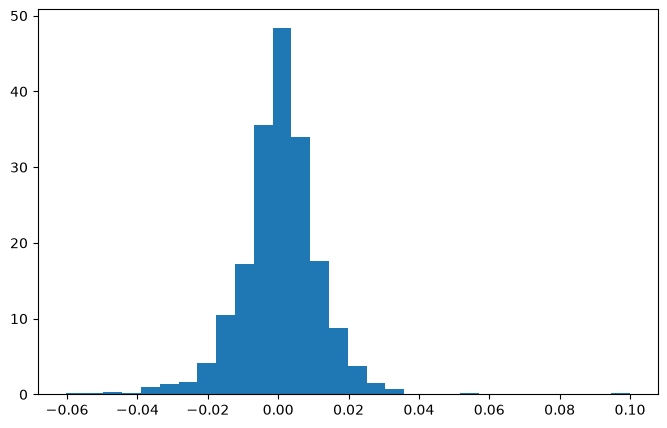

In [31]:
for B in [30, 60, 120]:
    counts, bin_edges = np.histogram(
        spy_returns,
        bins=B,
        density=True
    )

    bin_widths = np.diff(bin_edges)

    plt.figure(figsize=(8, 5))
    plt.bar(
        bin_edges[:-1],
        counts,
        width=bin_widths,
        align="edge"
    )

    plt.xlim(q001, q999)
    plt.xlabel("Daily log-return")
    plt.ylabel("Density")
    plt.title(f"SPY Daily Log-Returns — {B} bins")
    plt.show()

    area = np.sum(counts * bin_widths)
    print(f"B = {B}, total area = {area:.6f}")

In [32]:
aapl_price = aapl["Adj Close"].dropna()

In [33]:
aapl_returns = np.log(aapl_price) - np.log(aapl_price.shift(1))
aapl_returns = aapl_returns.dropna()

NameError: name 'q_001' is not defined

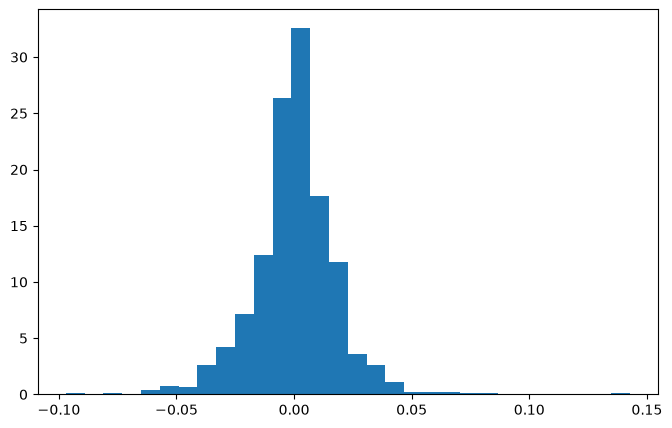

In [ ]:
for B in [30, 60, 120]:
    counts, bin_edges = np.histogram(
        aapl_returns,
        bins=B,
        density=True
    )

    bin_widths = np.diff(bin_edges)

    plt.figure(figsize=(8, 5))
    plt.bar(
        bin_edges[:-1],
        counts,
        width=bin_widths,
        align="edge"
    )

    plt.xlim(q001, q999)
    plt.xlabel("Daily log-return")
    plt.ylabel("Density")
    plt.title(f"AAPL Daily Log-Returns — {B} bins")
    plt.show()

    area = np.sum(counts * bin_widths)
    print(f"B = {B}, total area = {area:.6f}")

In [35]:
#problem 1b

In [36]:
spy.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2022-01-03,449.486450,477.709991,477.850006,473.850006,476.299988,72668200
2022-01-04,449.335907,477.549988,479.980011,475.579987,479.220001,71178700
2022-01-05,440.707672,468.380005,477.980011,468.279999,477.160004,104538900
2022-01-06,440.293671,467.940002,470.820007,465.429993,467.890015,86858900
2022-01-07,438.553040,466.089996,469.200012,464.649994,467.950012,85111600


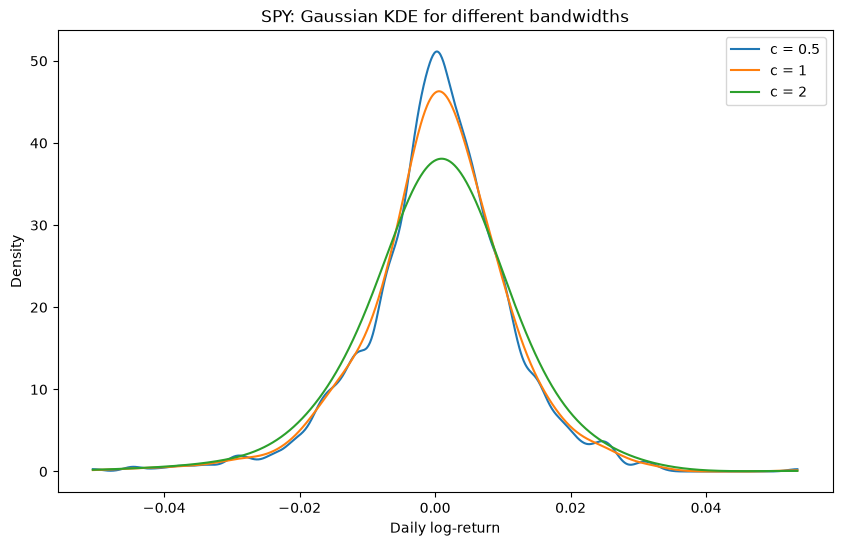

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Convert returns from a one-column DataFrame to a 1D array
data = spy_returns.to_numpy().ravel()

# Number of observations
n = len(data)

# Scott's bandwidth factor
h_scott = n ** (-1 / 5)

# Standard deviation of the data
s = np.std(data, ddof=1)

# Reference bandwidth
h = h_scott * s

# x-values over which we evaluate the KDE
x = np.linspace(
    np.quantile(data, 0.001),
    np.quantile(data, 0.999),
    1000
)

# Gaussian KDE function
def gaussian_kde_manual(x, data, bandwidth):
    n = len(data)

    u = (x[:, None] - data[None, :]) / bandwidth

    kernel_values = (
        1 / np.sqrt(2 * np.pi)
        * np.exp(-0.5 * u**2)
    )

    return np.sum(kernel_values, axis=1) / (n * bandwidth)


# Plot the three bandwidths
plt.figure(figsize=(10, 6))

for c in [0.5, 1, 2]:
    bandwidth = c * h

    density = gaussian_kde_manual(
        x,
        data,
        bandwidth
    )

    plt.plot(
        x,
        density,
        label=f"c = {c}"
    )

plt.xlabel("Daily log-return")
plt.ylabel("Density")
plt.title("SPY: Gaussian KDE for different bandwidths")
plt.legend()
plt.show()

In [38]:
mu_spy = np.mean(data)

sigma_spy = np.sqrt(
    np.mean((data - mu_spy)**2)
)

print("SPY Gaussian MLE:")
print("mu =", mu_spy)
print("sigma =", sigma_spy)

SPY Gaussian MLE:
mu = 0.0004106850659191128
sigma = 0.01132035464845923


In [39]:
aapl_price = aapl["Adj Close"].dropna()

In [40]:
aapl_returns = np.log(
    aapl_price / aapl_price.shift(1)
).dropna()

In [41]:
aapl_data = aapl_returns.to_numpy().ravel()

mu_aapl = np.mean(aapl_data)

sigma_aapl = np.sqrt(
    np.mean((aapl_data - mu_aapl)**2)
)

print("AAPL Gaussian MLE:")
print("mu =", mu_aapl)
print("sigma =", sigma_aapl)

AAPL Gaussian MLE:
mu = 0.00042114395031343983
sigma = 0.017885836798774646


In [42]:
from scipy import optimize
print("optimize works")

optimize works


In [43]:
import numpy as np
from scipy import optimize
from scipy.special import gammaln

In [44]:
import numpy as np
from scipy import optimize
from scipy.special import gammaln


# ============================================================
# 1. Prepare the return data
# ============================================================

spy_data = spy_returns.to_numpy().ravel()
aapl_data = aapl_returns.to_numpy().ravel()


# ============================================================
# 2. Gaussian MLE
# ============================================================

def gaussian_mle(data):
    mu = np.mean(data)

    # MLE variance uses 1/n, NOT 1/(n-1)
    sigma = np.sqrt(np.mean((data - mu)**2))

    return mu, sigma


mu_spy, sigma_spy = gaussian_mle(spy_data)
mu_aapl, sigma_aapl = gaussian_mle(aapl_data)


# ============================================================
# 3. Student-t negative log-likelihood
# ============================================================

def student_t_nll(theta, data):
    # theta contains:
    # theta[0] = mu
    # theta[1] = log(s)
    # theta[2] = log(nu)

    mu = theta[0]
    s = np.exp(theta[1])
    nu = np.exp(theta[2])

    z = (data - mu) / s

    log_pdf = (
        gammaln((nu + 1) / 2)
        - gammaln(nu / 2)
        - 0.5 * np.log(nu * np.pi)
        - np.log(s)
        - ((nu + 1) / 2) * np.log1p(z**2 / nu)
    )

    # We minimize negative log-likelihood
    return -np.sum(log_pdf)


# ============================================================
# 4. Student-t MLE
# ============================================================

def student_t_mle(data, sigma_start):
    best_result = None

    # Try several starting values for nu
    for nu_start in [2.5, 3, 5, 10, 20]:
        theta0 = np.array([
            np.mean(data),
            np.log(sigma_start),
            np.log(nu_start)
        ])

        result = optimize.minimize(
            student_t_nll,
            theta0,
            args=(data,),
            method="Nelder-Mead",
            options={"maxiter": 10000}
        )

        if best_result is None or result.fun < best_result.fun:
            best_result = result

    mu = best_result.x[0]
    s = np.exp(best_result.x[1])
    nu = np.exp(best_result.x[2])

    return mu, s, nu, best_result


mu_t_spy, s_t_spy, nu_t_spy, result_spy = student_t_mle(
    spy_data, sigma_spy
)

mu_t_aapl, s_t_aapl, nu_t_aapl, result_aapl = student_t_mle(
    aapl_data, sigma_aapl
)

print("SPY Student-t:")
print(mu_t_spy, s_t_spy, nu_t_spy, result_spy.success)

print("\nAAPL Student-t:")
print(mu_t_aapl, s_t_aapl, nu_t_aapl, result_aapl.success)


# ============================================================
# 5. Print the results
# ============================================================

print("Gaussian MLE")
print("---------------------------")

print("SPY")
print(f"mu    = {mu_spy:.8f}")
print(f"sigma = {sigma_spy:.8f}")

print("\nAAPL")
print(f"mu    = {mu_aapl:.8f}")
print(f"sigma = {sigma_aapl:.8f}")


print("\n\nStudent-t MLE")
print("---------------------------")

print("SPY")
print(f"mu = {mu_t_spy:.8f}")
print(f"s  = {s_t_spy:.8f}")
print(f"nu = {nu_t_spy:.8f}")

print("\nAAPL")
print(f"mu = {mu_t_aapl:.8f}")
print(f"s  = {s_t_aapl:.8f}")
print(f"nu = {nu_t_aapl:.8f}")


# Check whether the optimization converged
print("\n\nOptimization status")
print("---------------------------")
print("SPY:", result_spy.success, "-", result_spy.message)
print("AAPL:", result_aapl.success, "-", result_aapl.message)

SPY Student-t:
0.0007415904524876117 0.007829022045598686 3.7008242986565234 True

AAPL Student-t:
0.0007598558515757012 0.012214247924066609 3.5153188764246206 True
Gaussian MLE
---------------------------
SPY
mu    = 0.00041069
sigma = 0.01132035

AAPL
mu    = 0.00042114
sigma = 0.01788584


Student-t MLE
---------------------------
SPY
mu = 0.00074159
s  = 0.00782902
nu = 3.70082430

AAPL
mu = 0.00075986
s  = 0.01221425
nu = 3.51531888


Optimization status
---------------------------
SPY: True - Optimization terminated successfully.
AAPL: True - Optimization terminated successfully.


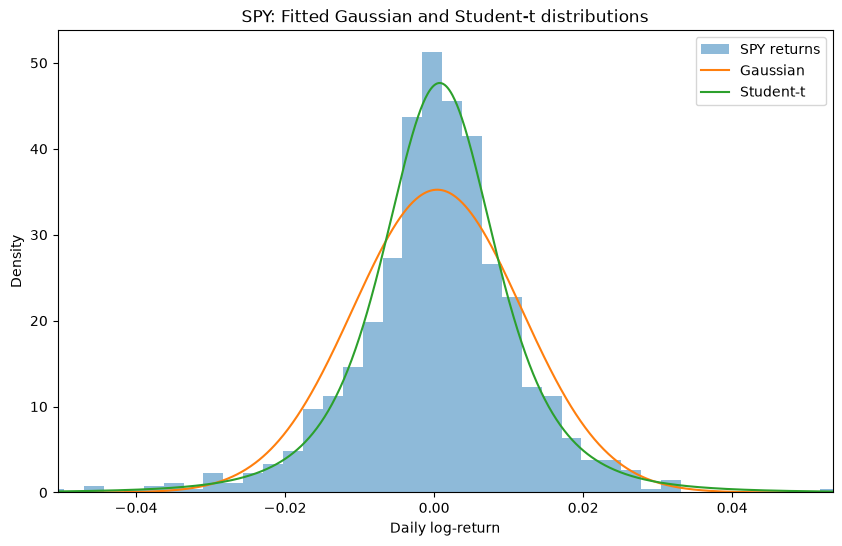

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

# ============================================================
# 1. X-axis: empirical 0.1% to 99.9% range
# ============================================================

x_spy = np.linspace(
    np.quantile(spy_data, 0.001),
    np.quantile(spy_data, 0.999),
    1000
)


# ============================================================
# 2. Gaussian fitted density
# ============================================================

gaussian_density_spy = (
    1 / (sigma_spy * np.sqrt(2 * np.pi))
    * np.exp(
        -0.5 * ((x_spy - mu_spy) / sigma_spy) ** 2
    )
)


# ============================================================
# 3. Student-t fitted density
# ============================================================

student_t_density_spy = (
    1 / s_t_spy
    * gamma((nu_t_spy + 1) / 2)
    / (
        np.sqrt(nu_t_spy * np.pi)
        * gamma(nu_t_spy / 2)
    )
    * (
        1
        + ((x_spy - mu_t_spy) / s_t_spy) ** 2 / nu_t_spy
    ) ** (-(nu_t_spy + 1) / 2)
)


# ============================================================
# 4. Histogram + fitted distributions
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    spy_data,
    bins=60,
    density=True,
    alpha=0.5,
    label="SPY returns"
)

plt.plot(
    x_spy,
    gaussian_density_spy,
    label="Gaussian"
)

plt.plot(
    x_spy,
    student_t_density_spy,
    label="Student-t"
)

plt.xlim(
    np.quantile(spy_data, 0.001),
    np.quantile(spy_data, 0.999)
)

plt.xlabel("Daily log-return")
plt.ylabel("Density")
plt.title("SPY: Fitted Gaussian and Student-t distributions")
plt.legend()
plt.show()

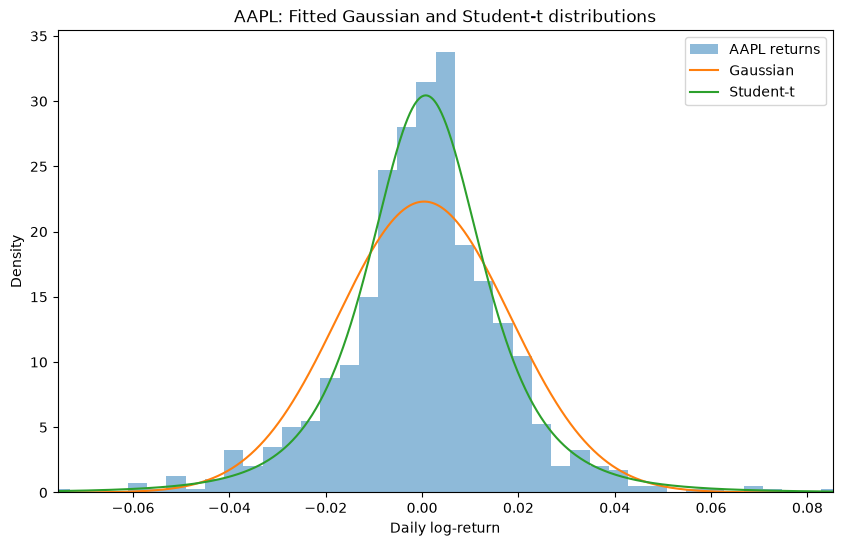

In [46]:
# ============================================================
# AAPL: fitted Gaussian and Student-t distributions
# ============================================================

# 1. X-axis: empirical 0.1% to 99.9% range
x_aapl = np.linspace(
    np.quantile(aapl_data, 0.001),
    np.quantile(aapl_data, 0.999),
    1000
)


# 2. Gaussian fitted density
gaussian_density_aapl = (
    1 / (sigma_aapl * np.sqrt(2 * np.pi))
    * np.exp(
        -0.5 * ((x_aapl - mu_aapl) / sigma_aapl) ** 2
    )
)


# 3. Student-t fitted density
student_t_density_aapl = (
    1 / s_t_aapl
    * gamma((nu_t_aapl + 1) / 2)
    / (
        np.sqrt(nu_t_aapl * np.pi)
        * gamma(nu_t_aapl / 2)
    )
    * (
        1
        + ((x_aapl - mu_t_aapl) / s_t_aapl) ** 2
        / nu_t_aapl
    ) ** (-(nu_t_aapl + 1) / 2)
)


# 4. Histogram + fitted distributions
plt.figure(figsize=(10, 6))

plt.hist(
    aapl_data,
    bins=60,
    density=True,
    alpha=0.5,
    label="AAPL returns"
)

plt.plot(
    x_aapl,
    gaussian_density_aapl,
    label="Gaussian"
)

plt.plot(
    x_aapl,
    student_t_density_aapl,
    label="Student-t"
)

plt.xlim(
    np.quantile(aapl_data, 0.001),
    np.quantile(aapl_data, 0.999)
)

plt.xlabel("Daily log-return")
plt.ylabel("Density")
plt.title("AAPL: Fitted Gaussian and Student-t distributions")
plt.legend()
plt.show()

In [47]:
# Select the Adjusted Close prices
spy_price = spy["Adj Close"].dropna()

# Calculate daily log-returns
spy_returns = np.log(
    spy_price / spy_price.shift(1)
).dropna()

# Convert to a 1D array for our calculations
spy_data = spy_returns.to_numpy().ravel()

print(spy_returns.head())
print("Number of returns:", len(spy_data))

Ticker           SPY
Date                
2022-01-04 -0.000335
2022-01-05 -0.019389
2022-01-06 -0.000940
2022-01-07 -0.003961
2022-01-10 -0.001245
Number of returns: 1002


In [48]:
q_spy_01 = np.quantile(spy_data, 0.01)
q_spy_99 = np.quantile(spy_data, 0.99)

print("SPY 1% quantile:", q_spy_01)
print("SPY 99% quantile:", q_spy_99)

SPY 1% quantile: -0.032518040443552054
SPY 99% quantile: 0.026044966344214805


In [49]:
# Gaussian MLE parameters for SPY
mu_spy = np.mean(spy_data)

sigma_spy = np.sqrt(
    np.mean((spy_data - mu_spy)**2)
)

print("mu =", mu_spy)
print("sigma =", sigma_spy)

mu = 0.00041068506591911195
sigma = 0.011320354648459234


In [50]:
from scipy.special import ndtr

p_gaussian_left = ndtr(
    (q_spy_01 - mu_spy) / sigma_spy
)

p_gaussian_right = 1 - ndtr(
    (q_spy_99 - mu_spy) / sigma_spy
)

print("Gaussian left-tail probability:", p_gaussian_left)
print("Gaussian right-tail probability:", p_gaussian_right)

Gaussian left-tail probability: 0.001814054494699813
Gaussian right-tail probability: 0.01177348584521376


In [51]:
from scipy.special import betainc

def student_t_cdf(x, mu, s, nu):
    z = (x - mu) / s

    if z >= 0:
        return 1 - 0.5 * betainc(
            nu / 2,
            0.5,
            nu / (nu + z**2)
        )
    else:
        return 0.5 * betainc(
            nu / 2,
            0.5,
            nu / (nu + z**2)
        )


p_student_left = student_t_cdf(
    q_spy_01,
    mu_t_spy,
    s_t_spy,
    nu_t_spy
)

p_student_right = 1 - student_t_cdf(
    q_spy_99,
    mu_t_spy,
    s_t_spy,
    nu_t_spy
)

print("Student-t left-tail probability:", p_student_left)
print("Student-t right-tail probability:", p_student_right)

Student-t left-tail probability: 0.007768062840392584
Student-t right-tail probability: 0.017844615790827856


In [52]:
q_aapl_01 = np.quantile(aapl_data, 0.01)
q_aapl_99 = np.quantile(aapl_data, 0.99)

print("AAPL 1% quantile:", q_aapl_01)
print("AAPL 99% quantile:", q_aapl_99)

AAPL 1% quantile: -0.04919914205417182
AAPL 99% quantile: 0.0441474408996137


In [54]:
from scipy.special import ndtr

p_gaussian_left_aapl = ndtr(
    (q_aapl_01 - mu_aapl) / sigma_aapl
)

p_gaussian_right_aapl = 1 - ndtr(
    (q_aapl_99 - mu_aapl) / sigma_aapl
)

print("AAPL Gaussian left-tail probability:", p_gaussian_left_aapl)
print("AAPL Gaussian right-tail probability:", p_gaussian_right_aapl)

AAPL Gaussian left-tail probability: 0.0027662177845478703
AAPL Gaussian right-tail probability: 0.007247744260554856


In [61]:
p_student_left_aapl = student_t_cdf(
    q_aapl_01,
    mu_t_aapl,
    s_t_aapl,
    nu_t_aapl
)

p_student_right_aapl = 1 - student_t_cdf(
    q_aapl_99,
    mu_t_aapl,
    s_t_aapl,
    nu_t_aapl
)

print("AAPL Student-t left-tail probability:", p_student_left_aapl)
print("AAPL Student-t right-tail probability:", p_student_right_aapl)

AAPL Student-t left-tail probability: 0.009701056111256476
AAPL Student-t right-tail probability: 0.014701616005970308


In [63]:
mu_check_spy = np.mean(spy_data)

sigma_check_spy = np.sqrt(
    np.mean((spy_data - mu_check)**2)
)

print("mu =", mu_check_spy)
print("sigma =", sigma_check_spy)

mu = 0.00041068506591911195
sigma = 0.011320354648459234


In [64]:
mu_check_aapl = np.mean(aapl_data)

sigma_check_aapl = np.sqrt(
    np.mean((aapl_data - mu_check_aapl)**2)
)

print("AAPL mu =", mu_check_aapl)
print("AAPL sigma =", sigma_check_aapl)

AAPL mu = 0.00042114395031343983
AAPL sigma = 0.017885836798774646


In [71]:
import scipy
from scipy import stats

def nll(theta, x):
    nu, loc, scale = theta
    if nu <= 0 or scale <= 0:
        return np.inf
    return -np.sum(stats.t.logpdf(x, df=nu, loc=loc, scale=scale))

r = spy_data
theta0 = np.array([5.0, np.mean(r), np.std(r)])
res = scipy.optimize.minimize(nll, theta0, args=(r,))

print(res.x)

[3.70076648e+00 7.41597849e-04 7.82897394e-03]


c:\Users\nickh\OneDrive\Documenten\big-data-science-in-finance\.venv\Lib\site-packages\scipy\optimize\_numdiff.py:710: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


In [ ]:
#Problem 3

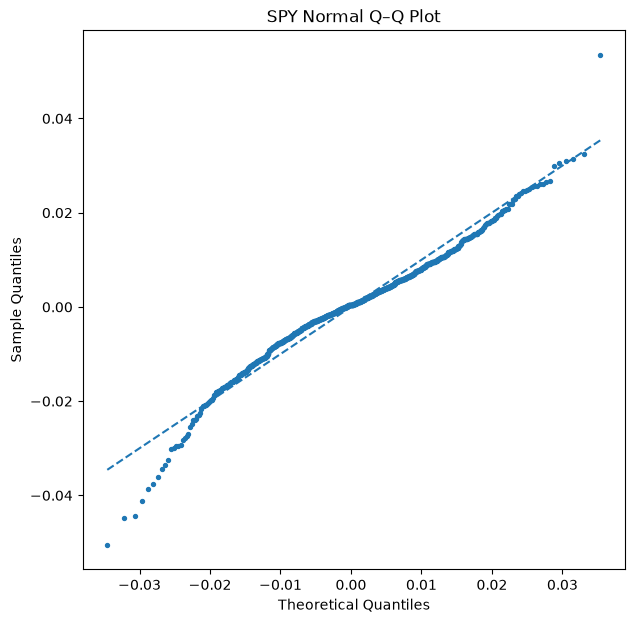

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ndtri

p = np.linspace(0.001, 0.999, 1000)

theoretical_normal = mu_spy + sigma_spy * ndtri(p)
sample_quantiles = np.quantile(spy_data, p)

plt.figure(figsize=(7, 7))
plt.scatter(theoretical_normal, sample_quantiles, s=8)

plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.title("SPY Normal Q–Q Plot")

plt.plot(
    theoretical_normal,
    theoretical_normal,
    linestyle="--"
)

plt.show()

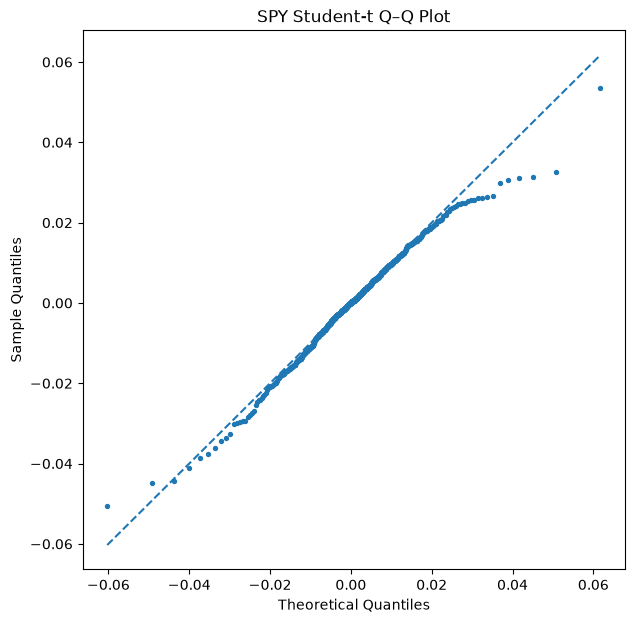

In [73]:
from scipy.special import stdtrit

p = np.linspace(0.001, 0.999, 1000)

theoretical_t = (
    mu_t_spy
    + s_t_spy * stdtrit(nu_t_spy, p)
)

sample_quantiles = np.quantile(spy_data, p)

plt.figure(figsize=(7, 7))
plt.scatter(theoretical_t, sample_quantiles, s=8)

plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.title("SPY Student-t Q–Q Plot")

plt.plot(
    theoretical_t,
    theoretical_t,
    linestyle="--"
)

plt.show()

In [ ]:
#problem 4

In [77]:
spy_losses = -spy_data
VaR_95_spy = np.quantile(spy_losses, 0.95)
VaR_99_spy = np.quantile(spy_losses, 0.99)

print("SPY VaR 95%:", VaR_95_spy)
print("SPY VaR 99%:", VaR_99_spy)

SPY VaR 95%: 0.017237738863327495
SPY VaR 99%: 0.032518040443552075


In [78]:
ES_95_spy = np.mean(spy_losses[spy_losses >= VaR_95_spy])
ES_99_spy = np.mean(spy_losses[spy_losses >= VaR_99_spy])

print("SPY ES 95%:", ES_95_spy)
print("SPY ES 99%:", ES_99_spy)

SPY ES 95%: 0.02640741194874208
SPY ES 99%: 0.04131449368664753


In [79]:
aapl_losses = -aapl_data

VaR_95_aapl = np.quantile(aapl_losses, 0.95)
VaR_99_aapl = np.quantile(aapl_losses, 0.99)

ES_95_aapl = np.mean(aapl_losses[aapl_losses >= VaR_95_aapl])
ES_99_aapl = np.mean(aapl_losses[aapl_losses >= VaR_99_aapl])

print("AAPL VaR 95%:", VaR_95_aapl)
print("AAPL VaR 99%:", VaR_99_aapl)
print("AAPL ES 95%:", ES_95_aapl)
print("AAPL ES 99%:", ES_99_aapl)

AAPL VaR 95%: 0.02915970834321688
AAPL VaR 99%: 0.04919914205417183
AAPL ES 95%: 0.04083745889882075
AAPL ES 99%: 0.059230888401788896


In [80]:
from scipy.special import ndtri

def gaussian_var_es(mu, sigma, alpha):
    z = ndtri(alpha)

    VaR = -mu + sigma * z
    ES = -mu + sigma * (
        np.exp(-0.5 * z**2) / np.sqrt(2 * np.pi)
    ) / (1 - alpha)

    return VaR, ES


for name, mu, sigma in [
    ("SPY", mu_spy, sigma_spy),
    ("AAPL", mu_aapl, sigma_aapl)
]:
    for alpha in [0.95, 0.99]:
        VaR, ES = gaussian_var_es(mu, sigma, alpha)

        print(f"{name} α={alpha}")
        print(f"  Gaussian VaR: {VaR:.6f}")
        print(f"  Gaussian ES:  {ES:.6f}")

SPY α=0.95
  Gaussian VaR: 0.018210
  Gaussian ES:  0.022940
SPY α=0.99
  Gaussian VaR: 0.025924
  Gaussian ES:  0.029760
AAPL α=0.95
  Gaussian VaR: 0.028998
  Gaussian ES:  0.036472
AAPL α=0.99
  Gaussian VaR: 0.041188
  Gaussian ES:  0.047248
